# Run Inference Using Python

https://kserve.github.io/website/docs/model-serving/predictive-inference/frameworks/onnx

In [1]:
# Imports
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

In [2]:
# Configuration
MODEL_NAME = 'mosaic'
IMAGE_PATH = '/home/jovyan/scratch-volume/models/mosaic/amber.jpg'
IMAGE_SIZE = (224, 224)

# Resolve inference service URL
result = !kubectl get inferenceservices style-sample -o jsonpath='{.status.address.url}'
SERVICE_HOSTNAME = result[0].strip()

print(f'SERVICE_HOSTNAME: {SERVICE_HOSTNAME}')

SERVICE_HOSTNAME: http://style-sample.kubeflow-m-xochicale.svc.cluster.local


Input tensor shape: (1, 3, 224, 224)


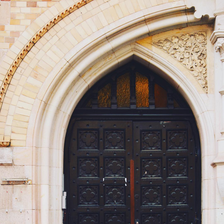

In [3]:
def load_image(path: str, size=(224, 224)):
    image = Image.open(path).convert('RGB')
    image = image.resize(size, Image.Resampling.LANCZOS)

    array = np.array(image, dtype=np.float32)
    tensor = np.transpose(array, (2, 0, 1))
    tensor = np.expand_dims(tensor, axis=0)

    return image, tensor

image, input_tensor = load_image(IMAGE_PATH, IMAGE_SIZE)
print('Input tensor shape:', input_tensor.shape)
image

## Build inference request

In [4]:
payload = {
    'inputs': [{
        'name': 'input1',
        'shape': list(input_tensor.shape),
        'datatype': 'FP32', # ONNX model expects float32
        'data': input_tensor.tolist(),
    }]
}

payload.keys()


dict_keys(['inputs'])

## Run inference

In [5]:
api_endpoint = f'{SERVICE_HOSTNAME}/v2/models/{MODEL_NAME}/infer'

headers = {
    'Content-Type': 'application/json',
    'Accept': 'application/json',
    'Host': SERVICE_HOSTNAME.replace('http://', '').replace('https://', '')
}

response = requests.post(
    api_endpoint,
    headers=headers,
    data=json.dumps(payload),
    timeout=60,
)

print('Status code:', response.status_code)
response.raise_for_status()

Status code: 200


## Post-process and display result

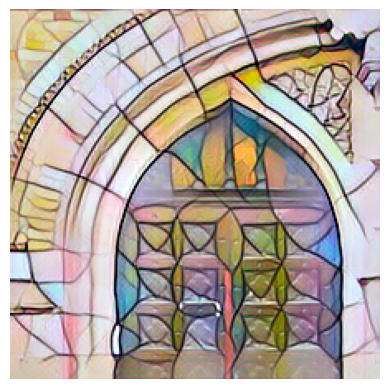

In [6]:
response_json = response.json()

output = np.array(response_json['outputs'][0]['data'], dtype=np.float32)
output = output.reshape(3, 224, 224)

result = np.clip(output, 0, 255)
result = result.transpose(1, 2, 0).astype(np.uint8)

result_image = Image.fromarray(result)

plt.imshow(result_image)
plt.axis('off')
plt.show()